In [9]:
import pandas as pd
import json

with open("/content/ferrari[1].json", "r", encoding="utf-8") as f:
    data = json.load(f)


In [10]:
from pandas import json_normalize


main_comments = json_normalize(data, sep='_')


replies = []
for comment in data:
    for reply in comment.get("replies", []):
        reply["parent_comment_id"] = comment["comment_id"]
        replies.append(reply)


df_main = pd.DataFrame(main_comments)
df_replies = pd.DataFrame(replies)


df_all = pd.concat([df_main[['comment_id', 'comment']], df_replies[['comment_id', 'comment']]], ignore_index=True)


In [11]:
df_all.head(10)

,comment_id,comment
0,7437156113642521351,How doni buy this watch?
1,7436012563587973910,Ferrari wird euch anklagen weil ihr sowas mit ...
2,7456549457859445535,"Dang, that’s pretty cool. But now a Rolex AD w..."
3,7452075414547956502,amazing some people are so talented. i dont kn...
4,7440110770992218901,Đang xịn xò cái như đồng hồ con nít đeo ☹️
5,7435981307491926806,io ho un Airking super precision quanto costa ...
6,7435916007157777174,Se L'avvocato Agnelli potesse vedere questo Ca...
7,7436764016872440583,cool i want one 😎
8,7437626038290547486,"It looks amazing, that being said, I think I w..."
9,7436786659407332104,It’s nice work but should be used for a cheape...


In [12]:
df_all.shape

(647, 2)

In [13]:
!pip install pandas
!pip install textblob

In [14]:
import pandas as pd
from textblob import TextBlob

In [15]:
sentiments = []
polarities = []
for text in df_all['comment']:
    blob = TextBlob(text)
    sentiments.append(blob.sentiment.subjectivity)
    polarities.append(blob.sentiment.polarity)

df_all['sentiment_subjectivity'] = sentiments
df_all['sentiment_polarity'] = polarities

In [16]:
df_all

,comment_id,comment,sentiment_subjectivity,sentiment_polarity
0,7437156113642521351,How doni buy this watch?,0.000,0.00
1,7436012563587973910,Ferrari wird euch anklagen weil ihr sowas mit ...,0.000,0.00
2,7456549457859445535,"Dang, that’s pretty cool. But now a Rolex AD w...",0.825,0.30
3,7452075414547956502,amazing some people are so talented. i dont kn...,0.900,0.65
4,7440110770992218901,Đang xịn xò cái như đồng hồ con nít đeo ☹️,0.000,0.00
...,...,...,...,...
642,7450648303928574753,Are injecție directă,0.000,0.00
643,7450538671743386390,Da e replica,0.000,0.00
644,7450209757594911510,Și eu 🤣,0.000,0.00
645,7450218859342447392,Și mai găsim câteva persoane interesate🤣🤣🤣🤣,0.000,0.00


In [17]:
! pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.7 MB/s eta 0:00:00


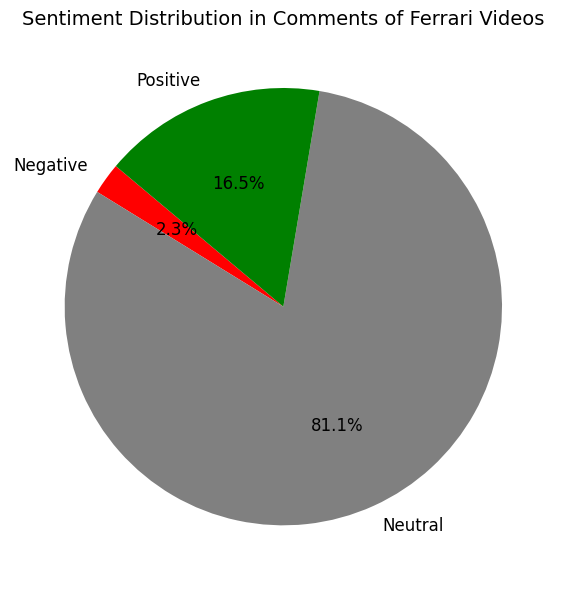

In [25]:
import pandas as pd
import matplotlib.pyplot as plt


df_all['sentiment_label'] = df_all['sentiment_polarity'].apply(
    lambda x: 'Positive' if x > 0 else 'Negative' if x < 0 else 'Neutral'
)


sentiment_percentages = df_all['sentiment_label'].value_counts(normalize=True).reindex(
    ['Negative', 'Neutral', 'Positive'], fill_value=0
) * 100


colors = ['red', 'gray', 'green']
plt.figure(figsize=(6, 6))
plt.pie(sentiment_percentages, labels=sentiment_percentages.index, colors=colors,
        autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})

plt.title('Sentiment Distribution in Comments of Ferrari Videos', fontsize=14)
plt.tight_layout()
plt.show()
